# Reactor Type: Slurry Bubble Column

Slurry bubble columns (SBCs) contain a gas-liquid-solid three-phase system: gas bubbles rise through a suspension of fine catalyst particles in a liquid. Applications include Fischer-Tropsch synthesis, hydrogenation, and bioprocessing. The key design parameters are gas holdup, mass-transfer coefficient $k_L a$, and axial mixing.

## Phase structure

| Phase | Contents | Flow direction |
|---|---|---|
| Large bubbles (fast) | Gas (high $U_G$) | Upward, slug-like |
| Dense phase (liquid + fine bubbles) | Liquid + catalyst + small bubbles | Recirculating |
| Solid catalyst | Suspended in liquid (slurry) | Entrained by liquid |

**Flow regimes**: homogeneous (small bubbles, $U_G < 0.05$ m/s) → heterogeneous (large + small bubbles coexist, $U_G > 0.05$ m/s).

## Governing equations (Krishna model)

**Small-bubble holdup** (dense phase):

$$\varepsilon_{\text{df}} = \frac{U_{\text{df}}}{V_{\text{small}}}, \quad V_{\text{small}} \approx 0.095\,\text{m/s}$$

**Large-bubble holdup** (correlations for column diameter $D_T$, $U_G$):

$$\varepsilon_b = 0.3\,D_T^{-0.18}\,U_b^{0.58}$$

**Total gas holdup**:

$$\varepsilon_G = \varepsilon_b + \varepsilon_{\text{df}}$$

**Overall volumetric mass-transfer coefficient**:

$$k_L a \approx \sqrt{\frac{D_L}{D_{L,\text{ref}}}}\,(0.5\varepsilon_b + \varepsilon_{\text{df}})$$

**Dispersion model** for dissolved gas concentration $c_L$ (liquid phase):

$$\frac{\partial c_L}{\partial t} = D_{ax,L}\frac{\partial^2 c_L}{\partial z^2} + k_L a (c_L^* - c_L) - k_r c_L$$

## PyMRM modeling strategy

| Term | Implementation |
|---|---|
| Liquid dispersion | `construct_grad`, `construct_div` with $D_{ax,L}$ |
| $k_L a$ mass transfer | Source term `kLa * (c_star - c_L)` per cell |
| Gas-phase balance | Simple plug-flow ODE for $c_G(z)$ |
| Liquid recirculation | Convective term with liquid velocity (optional) |
| Henry's law | $c_L^* = H \cdot p_G$ relates gas and liquid equilibrium |

eps_b  = 0.091  (large bubbles)
eps_df = 0.300  (dense phase)
eps_G  = 0.391  (total gas holdup)
kLa    = 0.3457 1/s
c*     = 1215.900 mol/m³


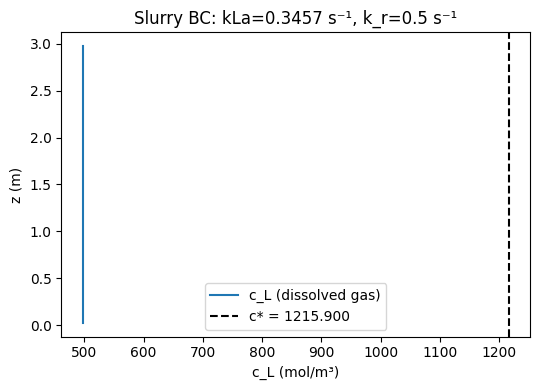

Average dissolved gas: 497.0259 mol/m³


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# ── Krishna model holdup correlations ─────────────────────────────
def slurry_holdup(U_G, D_T, V_small=0.095):
    '''Gas holdups for heterogeneous regime.'''
    # Large bubbles (heterogeneous regime contribution)
    U_b  = max(U_G - V_small * 0.3, 0)
    eps_b  = 0.3 * D_T**(-0.18) * U_b**0.58 if U_b > 0 else 0.0
    # Dense-phase (small bubbles)
    U_df = V_small * 0.3
    eps_df = min(U_df / V_small, 0.35)
    eps_G  = eps_b + eps_df
    return eps_b, eps_df, eps_G

def kLa_correlation(eps_b, eps_df, D_L, D_L_ref=2e-9):
    return np.sqrt(D_L / D_L_ref) * (0.5 * eps_b + eps_df)

# ── System parameters ─────────────────────────────────────────────
H_col  = 3.0         # column height [m]
D_T    = 0.15        # column diameter [m]
N      = 60
dz     = H_col / N
z      = (np.arange(N) + 0.5) * dz

U_G    = 0.10        # superficial gas velocity [m/s]
D_L    = 2e-9        # liquid-phase diffusivity [m²/s] (O₂ in water)
Dax_L  = 0.05        # axial dispersion in liquid [m²/s]
H_cc   = 1.2e-2      # Henry constant [mol/m³/Pa]
p_top  = 101325.0    # pressure at top [Pa]
k_r    = 0.5         # reaction rate [1/s]
c_L_in = 0.0         # inlet dissolved gas [mol/m³]

eps_b, eps_df, eps_G = slurry_holdup(U_G, D_T)
kLa    = kLa_correlation(eps_b, eps_df, D_L)
c_star = H_cc * p_top  # equilibrium dissolved gas at top pressure

print(f'eps_b  = {eps_b:.3f}  (large bubbles)')
print(f'eps_df = {eps_df:.3f}  (dense phase)')
print(f'eps_G  = {eps_G:.3f}  (total gas holdup)')
print(f'kLa    = {kLa:.4f} 1/s')
print(f'c*     = {c_star:.3f} mol/m³')

# ── Steady-state liquid balance ───────────────────────────────────
# -Dax d²c/dz² + kLa*(c - c*) + k_r*c = 0  with Neumann BCs
off = Dax_L / dz**2
sink = kLa + k_r
A_L  = sp.diags([-off, 2*off + sink, -off], [-1, 0, 1], shape=(N, N), format='csr')
# Neumann BC: zero flux at bottom and top
A_L  = A_L.tolil()
A_L[0, 0]  -= off   # zero-flux at bottom (ghost = c[0])
A_L[-1,-1] -= off   # zero-flux at top
A_L  = sp.csr_matrix(A_L)
rhs_L = np.full(N, kLa * c_star)
c_L   = spla.spsolve(A_L, rhs_L)

plt.figure(figsize=(5.5, 4))
plt.plot(c_L, z, label='c_L (dissolved gas)')
plt.axvline(c_star, ls='--', color='k', label=f'c* = {c_star:.3f}')
plt.xlabel('c_L (mol/m³)'); plt.ylabel('z (m)')
plt.title(f'Slurry BC: kLa={kLa:.4f} s⁻¹, k_r={k_r} s⁻¹')
plt.legend(); plt.tight_layout(); plt.show()
print(f'Average dissolved gas: {c_L.mean():.4f} mol/m³')

## Sensitivity: Effect of gas velocity on kLa

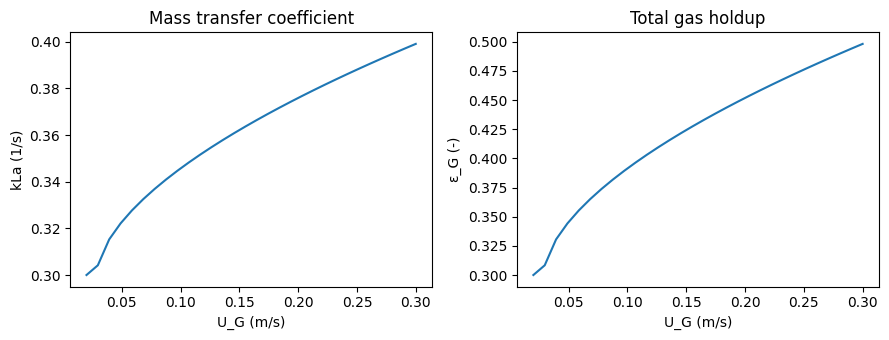

In [2]:
U_G_range = np.linspace(0.02, 0.30, 30)
kLa_range = []
epsG_range = []
for U in U_G_range:
    eb, edf, eG = slurry_holdup(U, D_T)
    kLa_range.append(kLa_correlation(eb, edf, D_L))
    epsG_range.append(eG)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
ax1.plot(U_G_range, kLa_range)
ax1.set_xlabel('U_G (m/s)'); ax1.set_ylabel('kLa (1/s)')
ax1.set_title('Mass transfer coefficient')
ax2.plot(U_G_range, epsG_range)
ax2.set_xlabel('U_G (m/s)'); ax2.set_ylabel('ε_G (-)')
ax2.set_title('Total gas holdup')
plt.tight_layout(); plt.show()

## Summary

- Heterogeneous regime dominates at $U_G > 0.05$ m/s; large bubbles bypass reactor
- $k_L a$ scales with holdup; small bubbles contribute more per unit volume than large ones
- Axial mixing in the liquid phase is significant; $D_{ax,L} \gg D_{mol}$
- Fine catalyst particles (dp < 50 μm) act as pseudo-liquid — no solid mass transfer limitation
- For scale-up: $k_L a$ correlations differ between lab (0.1 m) and industrial (5 m) columns